# CME Futures — Strategy Analysis

This notebook converts the cme_futures backtest registry into a
per-case-study strategy assessment. Every metric is reported with its
block-bootstrap 95% confidence interval, every comparison goes through
`backtest_paired_metrics`, and the holdout closure uses paired rather
than point-difference reasoning. Cross-case-study comparison is
reserved for Chapter 20.

**Learning objectives**

- Read uncertainty-aware backtest metrics (Sharpe ± CI, PSR, DSR) from
  the registry rather than transcribing point estimates.
- Trace a rank-1 lineage through pipeline stages with paired-bootstrap
  stage-transition deltas.
- Use the equal-weight universe benchmark (the 30-product CME panel)
  for both validation and holdout diagnostics.
- Trace a cross-stage rank-1 that climbs monotonically through every
  pipeline stage (signal → allocation → cost_sensitivity → risk_overlay)
  on a single prediction set, ending at the risk_overlay stage.

**Book reference**: Chapter 20, §20.1 (the §9 handoff feeds Ch20's
cross-case-study aggregation).

**Prerequisites**: case-study pipeline through `13_backtest`; the
case-study registry (`case_studies/cme_futures/run_log/registry.db`).

**Scope**: no training, no re-backtesting. Reads the case-study backtest
registry and, in §0, regenerates the two uncertainty tables it depends on
(`cohort_metrics`, `backtest_paired_metrics`) directly from the registry, so
the notebook is self-contained and does not depend on Chapter 20.

In [1]:
"""CME Futures — Strategy Analysis."""

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch  # ml4t.diagnostic loads cudart; torch must import first
import yaml

warnings.filterwarnings("ignore")

from ml4t.diagnostic.evaluation import PortfolioAnalysis
from ml4t.diagnostic.integration import (
    BacktestReportMetadata,
    generate_tearsheet_from_run_artifacts,
)

from case_studies.utils.backtest_explorer import BacktestExplorer
from case_studies.utils.benchmark import load_benchmark_metrics, load_benchmark_returns
from case_studies.utils.registry import (
    load_backtest_fold_metrics,
    load_backtest_metrics,
    load_paired_metrics,
)
from case_studies.utils.strategy_analysis import (
    ci_status,
    compute_operating_profile,
    fmt_gate,
    gate1_validation_sharpe_geq_zero,
    gate2_holdout_diff_not_excludes_zero_negatively,
    gate_passes,
    plot_concentration_curve,
    plot_equity_drawdown,
    plot_sharpe_waterfall,
    select_holdout_self_backtest,
    write_strategy_assessment,
)
from utils.paths import get_case_study_dir, get_output_dir

In [2]:
MAX_SYMBOLS = 0

In [3]:
CASE_STUDY = "cme_futures"
# Strategy-analysis convention: use the registry-resolved rank-1 label for the
# lineage analysis. The current rank-1 sits on fwd_ret_5d (matches setup.yaml
# primary); the prior rank-1 on fwd_ret_21d was superseded by the engine-schedule
# bounded rerun.
PRIMARY_LABEL = "fwd_ret_5d"
PERIODS_PER_YEAR = 252  # CME 5-day calendar
CASE_DIR = get_case_study_dir(CASE_STUDY)
OUTPUT_DIR = get_output_dir(20, CASE_STUDY)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)

explorer = BacktestExplorer(CASE_STUDY)
print(explorer)


def _fmt_ci(point: float | None, lo: float | None, hi: float | None, fmt: str = ".3f") -> str:
    """Compact `point [lo, hi]` formatter with NULL-safety."""
    if point is None:
        return "—"
    p = format(point, fmt)
    if lo is None or hi is None:
        return f"{p} [—, —]"
    return f"{p} [{format(lo, fmt)}, {format(hi, fmt)}]"


def _fmt(val: float | None, fmt: str = ".4f") -> str:
    return "—" if val is None else format(val, fmt)

BacktestExplorer('cme_futures', 695 runs: allocation=288, cost_sensitivity=44, holdout=1, risk_overlay=60, signal=302)


## §0 Regenerate the uncertainty tables

The strategy assessment reads two registry tables: `cohort_metrics`
(selection-bias DSR, White's Reality Check, PBO per cohort) and
`backtest_paired_metrics` (stage-transition and holdout paired-bootstrap
deltas). This case study is their sole producer, so the cell below
self-populates them the first time the notebook runs against a fresh
registry — which keeps the notebook self-contained (nothing downstream
depends on Chapter 20 having run first). The write is guarded: once the two
tables exist and are populated, the cell reads their row counts and writes
nothing, so re-executing the Ch20 capstone never mutates the frozen results
SSOT. The population itself is idempotent (keyed upserts) and reproduces the
stored values exactly.

In [4]:
import sqlite3 as _sqlite3

from case_studies.utils.cohort_metrics import compute_and_register
from case_studies.utils.paired_metrics import populate_paired_metrics

# Self-population is idempotent — it reproduces the registry's frozen values
# exactly — but running it still rewrites the case-study registry file. Guard
# it: populate only when the two derived tables are absent or empty (a fresh
# reader-generated registry). On an already-populated registry the notebook is
# a pure reader and touches nothing, so re-executing the Ch20 capstone never
# mutates the results SSOT.
_reg = CASE_DIR / "run_log" / "registry.db"
with _sqlite3.connect(str(_reg)) as _c:
    _tabs = {r[0] for r in _c.execute("SELECT name FROM sqlite_master WHERE type='table'")}
    _n_cohorts = (
        _c.execute("SELECT count(*) FROM cohort_metrics").fetchone()[0]
        if "cohort_metrics" in _tabs
        else 0
    )
    _n_pairs = (
        _c.execute("SELECT count(*) FROM backtest_paired_metrics").fetchone()[0]
        if "backtest_paired_metrics" in _tabs
        else 0
    )
if _n_cohorts == 0 or _n_pairs == 0:
    _cohort_counts = compute_and_register(CASE_STUDY)
    _paired_rows = populate_paired_metrics(CASE_STUDY)
    _n_cohorts = sum(_cohort_counts[k] for k in ("family", "stagelabel", "label"))
    _n_pairs = sum(1 for r in _paired_rows if "skip" not in r)
    print(
        f"cohort_metrics: {_n_cohorts} rows; backtest_paired_metrics: {_n_pairs} pairs (populated)"
    )
else:
    print(
        f"cohort_metrics: {_n_cohorts} rows; backtest_paired_metrics: {_n_pairs} pairs "
        "(already populated — reader mode, no write)"
    )

cohort_metrics: 34 rows; backtest_paired_metrics: 6 pairs (already populated — reader mode, no write)


## §1 Handoff from model analysis

The strategy phase inherits a single rank-1 model from
`12_model_analysis.py` §8. That model's daily-pooled IC and HAC-adjusted
95% CI define the upstream prior on backtest stability. The cross-stage
rank-1 lineage is GBM (`leaves_7_huber`) on the primary label
`fwd_ret_5d`. Its prediction-side daily-pooled IC sits at 0.015 with a
HAC-adjusted 95% CI that straddles zero (t = 1.08, p = 0.28 at lag 7).
Sharpe climbs monotonically through every pipeline stage on this single
prediction (signal 0.47 → allocation 0.84 → cost_sensitivity 0bps 0.88 →
risk_overlay 1.26); the cross-stage rank-1 by Sharpe is the
risk_overlay-stage backtest with a `score_weighted` top-k=5 allocator and
a 3.3% trailing-stop position-level overlay. The
30-product cross-section across 7 sectors concentrates exposure in a
small number of high-magnitude ranks, so a modest IC translates into a
sharper portfolio edge through cross-sectional magnitude.

In [5]:
# Rank-1 selection pools validation backtests across the holdout-eligible
# stages (signal / allocation / risk_overlay) and dedupes by prediction_hash,
# keeping the highest-Sharpe strategy_spec per trained model. Mirrors
# `20_strategy_synthesis/holdout.py::HOLDOUT_SELECTION_STAGES`.
_HOLDOUT_STAGES = ("signal", "allocation", "risk_overlay")
top_signal = (
    pl.concat(
        [explorer.best(stage=s, top_n=2000) for s in _HOLDOUT_STAGES],
        how="diagonal_relaxed",
    )
    .filter(pl.col("family") != "benchmark")
    .sort("sharpe", descending=True)
    .unique(subset=["prediction_hash"], keep="first", maintain_order=True)
    .head(1)
)
TOP_HASH = top_signal.row(0, named=True)["backtest_hash"]
TOP_PHASH = top_signal.row(0, named=True)["prediction_hash"]
RANK1_FAMILY = top_signal.row(0, named=True)["family"]
RANK1_CONFIG = top_signal.row(0, named=True)["config_name"]

# Pull the prediction-side IC with HAC CI from prediction_metrics.
import sqlite3

_db = CASE_DIR / "run_log" / "registry.db"
with sqlite3.connect(str(_db)) as _con:
    _row = _con.execute(
        "SELECT ic_mean_daily, ic_ci_lo, ic_ci_hi, ic_t_hac, ic_p_hac, ic_n_days, "
        "ic_hac_lag, ic_pct_positive "
        "FROM prediction_metrics WHERE prediction_hash = ?",
        (TOP_PHASH,),
    ).fetchone()

ic_mean, ic_lo, ic_hi, ic_t, ic_p, ic_ndays, ic_lag, ic_pct = _row

print(f"Rank-1: family={RANK1_FAMILY}, config={RANK1_CONFIG}, label={PRIMARY_LABEL}")
print(f"        prediction_hash={TOP_PHASH}, backtest_hash={TOP_HASH}")
print()
print("Daily-pooled IC (validation):")
print(f"  IC = {_fmt_ci(ic_mean, ic_lo, ic_hi, '.4f')}  (HAC, lag={int(ic_lag)})")
print(f"  t_HAC = {ic_t:.3f}, p_HAC = {ic_p:.3f}")
print(f"  n_days = {int(ic_ndays)}, pct_positive = {ic_pct:.1%}")
print(f"  CI status: {ci_status(ic_lo, ic_hi)}")

Rank-1: family=gbm, config=leaves_7_huber, label=fwd_ret_5d
        prediction_hash=cf863412cb23, backtest_hash=012708b18899

Daily-pooled IC (validation):
  IC = 0.0146 [-0.0119, 0.0412]  (HAC, lag=7)
  t_HAC = 1.080, p_HAC = 0.280
  n_days = 1290, pct_positive = 53.5%
  CI status: straddles_zero


Daily-pooled IC at the rank-1 prediction set sits at 0.015 with a
HAC-adjusted 95% CI [-0.012, 0.041] that straddles zero (t = 1.08,
p = 0.28 at lag 7); pct_positive sits at 53.5% over 1,290 trading days.
The strategy-stage Sharpe in §3, by contrast, excludes zero on the
positive side — so IC and Sharpe do not agree, and this is a genuine
IC-vs-Sharpe disconnect: broad rank accuracy is not resolved, while the
portfolio edge is. §2's lineage waterfall shows the Sharpe building from
the signal stage through every downstream stage on the same prediction.
The 30-product CME panel concentrates exposure across 7 sectors, so the
cross-sectional carry-momentum signal expresses itself through
magnitude in the top-K bucket rather than through broad rank accuracy —
exactly the profile a straddling IC with a resolved Sharpe implies.
§6's holdout closure tests whether the validation Sharpe transfers to
the disjoint 2024-2025 window.

**Kill conditions** are not encoded in `setup.yaml` for cme_futures.
The notebook evaluates two universal gates in §9: (i) the sharpe CI
lower bound ≥ 0 (signal-stage), and (ii) the holdout strategy-vs-EW
paired CI does not exclude zero on the negative side. Both are
reported as pass / partial / fail without verdict labels.

## §2 Search context, family comparison, and lineage waterfall

The signal stage of the locked sweep produced 302 validation
backtests across five model families and two label horizons. The rank-1
row emerges as one realization of that search; what matters next is
its context — where the rank-1 sits in the family-level distribution
and how its performance evolves through the pipeline stages.

In [6]:
ctx = explorer.search_context("signal")
search_table = pl.DataFrame(
    [
        {"metric": "Total signal backtests", "value": f"{ctx['total']:,}"},
        {"metric": "Mean Sharpe", "value": f"{ctx['mean_sharpe']:.3f}"},
        {"metric": "Median Sharpe", "value": f"{ctx['median_sharpe']:.3f}"},
        {"metric": "P90 Sharpe", "value": f"{ctx['p90_sharpe']:.3f}"},
        {"metric": "% positive Sharpe", "value": f"{ctx['pct_positive']:.1f}%"},
        {"metric": "Top-by-Sharpe in this sweep", "value": f"{ctx['champion_sharpe']:.3f}"},
        {"metric": "Top-by-Sharpe percentile", "value": f"{ctx['champion_percentile']:.1f}%"},
    ]
)
print("Signal-stage search context:")
print(search_table)

Signal-stage search context:
shape: (7, 2)
┌─────────────────────────────┬────────┐
│ metric                      ┆ value  │
│ ---                         ┆ ---    │
│ str                         ┆ str    │
╞═════════════════════════════╪════════╡
│ Total signal backtests      ┆ 302    │
│ Mean Sharpe                 ┆ 0.022  │
│ Median Sharpe               ┆ 0.056  │
│ P90 Sharpe                  ┆ 0.553  │
│ % positive Sharpe           ┆ 51.3%  │
│ Top-by-Sharpe in this sweep ┆ 1.126  │
│ Top-by-Sharpe percentile    ┆ 100.0% │
└─────────────────────────────┴────────┘


In [7]:
# Family comparison reads sharpe_ci95 from backtest_metrics directly so
# the forest plot can render proper error bars rather than median-only points.
with sqlite3.connect(str(CASE_DIR / "run_log" / "registry.db")) as _con:
    _famdf = pl.DataFrame(
        _con.execute(
            """
            SELECT
                t.family,
                bm.sharpe,
                bm.sharpe_ci95_lo,
                bm.sharpe_ci95_hi
            FROM backtest_metrics bm
            JOIN backtest_runs b ON bm.backtest_hash = b.backtest_hash
            JOIN prediction_sets p ON b.prediction_hash = p.prediction_hash
            JOIN training_runs t  ON p.training_hash = t.training_hash
            WHERE b.stage = 'signal'
              AND p.split = 'validation'
              AND bm.sharpe IS NOT NULL
              AND (bm.num_trades IS NULL OR bm.num_trades > 0)
            """
        ).fetchall(),
        schema=["family", "sharpe", "sharpe_ci95_lo", "sharpe_ci95_hi"],
        orient="row",
    )

family_summary = (
    _famdf.group_by("family")
    .agg(
        n=pl.len(),
        sharpe_median=pl.col("sharpe").median(),
        sharpe_q25=pl.col("sharpe").quantile(0.25),
        sharpe_q75=pl.col("sharpe").quantile(0.75),
        sharpe_max=pl.col("sharpe").max(),
        pct_positive=((pl.col("sharpe") > 0).sum() / pl.len() * 100),
    )
    .sort("sharpe_median", descending=True)
)
print("Family-level signal-stage Sharpe summary:")
print(family_summary)

Family-level signal-stage Sharpe summary:
shape: (5, 7)
┌────────────────┬─────┬───────────────┬────────────┬────────────┬────────────┬──────────────┐
│ family         ┆ n   ┆ sharpe_median ┆ sharpe_q25 ┆ sharpe_q75 ┆ sharpe_max ┆ pct_positive │
│ ---            ┆ --- ┆ ---           ┆ ---        ┆ ---        ┆ ---        ┆ ---          │
│ str            ┆ u32 ┆ f64           ┆ f64        ┆ f64        ┆ f64        ┆ f64          │
╞════════════════╪═════╪═══════════════╪════════════╪════════════╪════════════╪══════════════╡
│ latent_factors ┆ 44  ┆ 0.396656      ┆ 0.161744   ┆ 0.720265   ┆ 1.126253   ┆ 84.090909    │
│ gbm            ┆ 80  ┆ 0.262022      ┆ -0.365093  ┆ 0.363166   ┆ 0.560691   ┆ 60.0         │
│ tabular_dl     ┆ 52  ┆ -0.142952     ┆ -0.350401  ┆ 0.114669   ┆ 0.518816   ┆ 36.538462    │
│ linear         ┆ 120 ┆ -0.157705     ┆ -0.375713  ┆ 0.257877   ┆ 0.635391   ┆ 42.5         │
│ deep_learning  ┆ 6   ┆ -0.448443     ┆ -0.517319  ┆ -0.28702   ┆ -0.057182  ┆ 0.0      

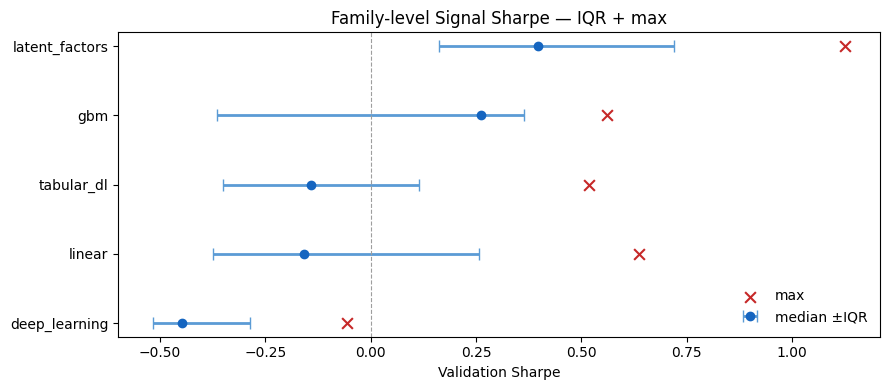

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
fams = family_summary["family"].to_list()
y = np.arange(len(fams))
medians = family_summary["sharpe_median"].to_numpy()
q25 = family_summary["sharpe_q25"].to_numpy()
q75 = family_summary["sharpe_q75"].to_numpy()
maxima = family_summary["sharpe_max"].to_numpy()

ax.errorbar(
    medians,
    y,
    xerr=[medians - q25, q75 - medians],
    fmt="o",
    color="#1565C0",
    ecolor="#5B9BD5",
    elinewidth=2.0,
    capsize=4,
    label="median ±IQR",
)
ax.scatter(maxima, y, marker="x", color="#C62828", s=60, label="max", zorder=5)
ax.axvline(0, color="#9E9E9E", linewidth=0.8, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(fams)
ax.set_xlabel("Validation Sharpe")
ax.set_title("Family-level Signal Sharpe — IQR + max")
ax.invert_yaxis()
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
fig.show()

At the signal stage, latent_factors leads the family medians (0.40,
84% positive, max 1.13) with GBM second (0.26, 60% positive, max 0.56);
linear and tabular_dl medians sit just below zero (-0.16 and -0.14), and
deep_learning trails the panel (-0.45, none positive). The rank-1 is a
GBM configuration not because GBM leads at the signal stage but because
its lineage climbs highest through the downstream allocation, cost, and
risk-overlay stages (§1 waterfall) — the cross-stage Sharpe, not the
signal-stage median, drives selection. The wide family-max points
highlight that the winner is a few exceptional configurations rather
than a stable family-wide advantage — the search-cost setting the
selection-adjustment in §3 is built for.

In [9]:
# Lineage with CI bars. champion_lineage gives stage hashes; we re-pull
# Sharpe CIs from backtest_metrics for each stage to render error bars.
lineage = explorer.champion_lineage(TOP_PHASH)
ci_lo: dict[str, float] = {}
ci_hi: dict[str, float] = {}
for stage_name, info in lineage.items():
    bm = load_backtest_metrics(CASE_STUDY, backtest_hash=info["backtest_hash"])
    if not bm.is_empty():
        row = bm.row(0, named=True)
        ci_lo[stage_name] = row.get("sharpe_ci95_lo")
        ci_hi[stage_name] = row.get("sharpe_ci95_hi")

print("Lineage stages present for rank-1 prediction:")
for s, info in lineage.items():
    lo, hi = ci_lo.get(s), ci_hi.get(s)
    print(f"  {s}: hash={info['backtest_hash']}, Sharpe={_fmt_ci(info['sharpe'], lo, hi)}")

# The rank-1 prediction now carries the full forward chain (signal →
# allocation → cost_sensitivity → risk_overlay) — every stage was
# re-swept in the 2026-05-17 unpark with per-product margin and $10M
# cash, so all four stage hashes resolve cleanly.
missing_stages = [s for s in ("cost_sensitivity", "risk_overlay") if s not in lineage]
if missing_stages:
    print()
    print(f"Stage transitions not run for this prediction: {missing_stages}")

Lineage stages present for rank-1 prediction:
  signal: hash=fba162f558c5, Sharpe=0.469 [-0.395, 1.347]
  allocation: hash=5289de0a7fca, Sharpe=0.836 [-0.050, 1.623]
  cost_sensitivity: hash=b7d55bc54fe1, Sharpe=0.884 [0.000, 1.666]
  risk_overlay: hash=012708b18899, Sharpe=1.264 [0.345, 2.087]


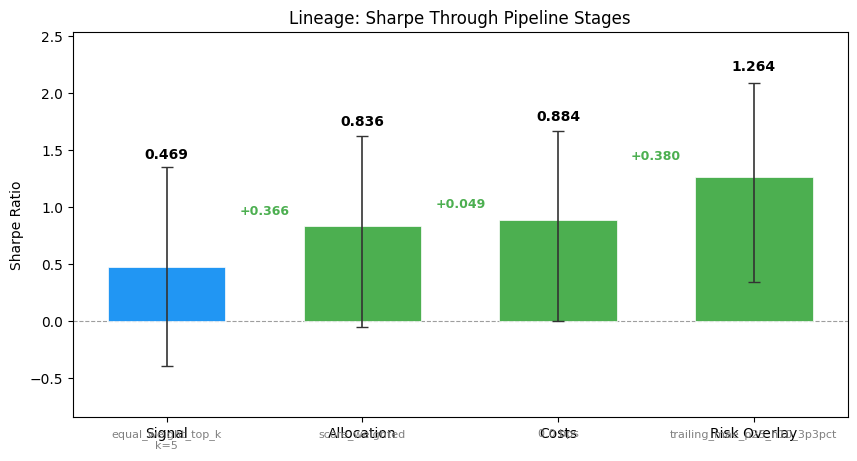

In [10]:
fig = plot_sharpe_waterfall(lineage, ci_lo=ci_lo, ci_hi=ci_hi)
fig.show()

In [11]:
# Stage-transition deltas via load_paired_metrics — never recompute paired
# metrics inline. For cme_futures the only present transition is signal →
# allocation, registered as benchmark_kind=signal_leader with the
# allocation-stage backtest as challenger.
ALLOC_HASH = lineage.get("allocation", {}).get("backtest_hash")
if ALLOC_HASH is not None:
    pair = load_paired_metrics(
        CASE_STUDY,
        challenger_hash=ALLOC_HASH,
        benchmark_kind="signal_leader",
    )
    if not pair.is_empty():
        r = pair.row(0, named=True)
        print("Stage transition: allocation challenger vs signal leader")
        print(
            f"  sharpe_diff = "
            f"{_fmt_ci(r['sharpe_diff'], r['sharpe_diff_ci95_lo'], r['sharpe_diff_ci95_hi'])}"
        )
        print(f"  p_value = {r['p_value']:.3f}")
        print(f"  prob_challenger_wins = {r['prob_challenger_wins']:.3f}")
        print(f"  CI status: {ci_status(r['sharpe_diff_ci95_lo'], r['sharpe_diff_ci95_hi'])}")

Stage transition: allocation challenger vs signal leader
  sharpe_diff = 0.362 [-0.135, 0.821]
  p_value = 0.134
  prob_challenger_wins = 0.918
  CI status: straddles_zero


Allocation-stage Sharpe rises above the signal-stage rank-1
(0.84 vs 0.47; paired diff +0.36 [-0.14, +0.82]). The diff CI straddles
zero (prob_chal_wins ≈ 0.92), so the lift is not resolved at 95% — but
the point estimate is operationally meaningful and consistent with the
cross-section's vol heterogeneity (energy moves 2–3× treasuries). The
equal-weight top-k selection at the signal stage implicitly over-weights
the highest-vol sectors; the `score_weighted top_k=5` allocator
reweights toward the model's ranking so each name contributes by
conviction. Downstream, cost_sensitivity at 0 bps re-establishes a
friction-free baseline (+0.05 vs allocation, mechanical — not an overlay
lift), and the 3.3% trailing-stop overlay adds a further +0.38 in point
estimate (paired diff +0.38 [-0.22, +1.04], unresolved in the
bootstrap-paired CI but the largest single-stage lift in the lineage).

Allocation: best Sharpe by top_k:
shape: (2, 4)
┌───────┬────────────────┬──────────┬──────────────┐
│ top_k ┆ allocator      ┆ sharpe   ┆ max_drawdown │
│ ---   ┆ ---            ┆ ---      ┆ ---          │
│ i64   ┆ str            ┆ f64      ┆ f64          │
╞═══════╪════════════════╪══════════╪══════════════╡
│ 5     ┆ score_weighted ┆ 0.835753 ┆ -0.551182    │
│ 10    ┆ score_weighted ┆ 0.756662 ┆ -0.495454    │
└───────┴────────────────┴──────────┴──────────────┘


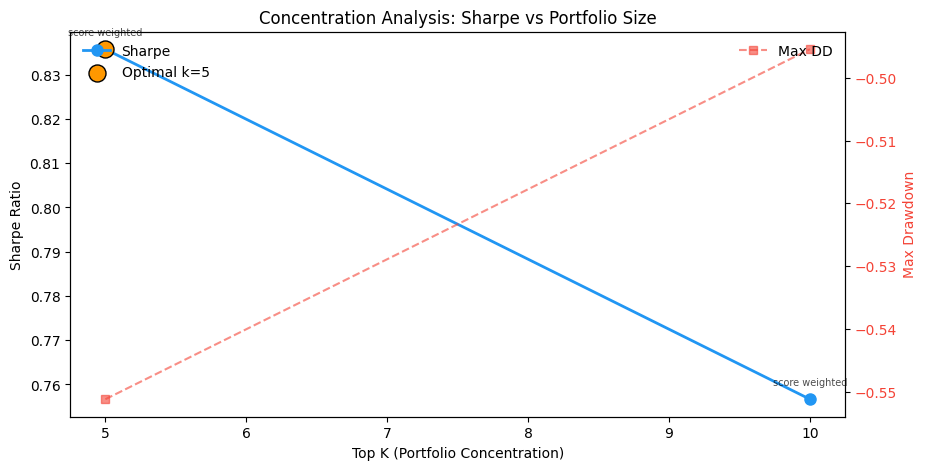

In [12]:
conc_df = explorer.concentration_curve(TOP_PHASH)
if not conc_df.is_empty():
    fig = plot_concentration_curve(conc_df)
    fig.show()
    best_per_k = conc_df.sort("sharpe", descending=True).group_by("top_k").first().sort("top_k")
    print("Allocation: best Sharpe by top_k:")
    print(best_per_k.select("top_k", "allocator", "sharpe", "max_drawdown"))
else:
    print("No concentration data — allocation stage absent for this prediction.")

With 30 products spread across 7 sectors, concentration is structurally
constrained: sextile concentration (top_k ≈ 5) leaves a single sector
dominating the long side, while half-universe concentration (top_k ≈
15) dilutes the cross-sectional carry signal. The concentration curve
captures this tension directly without imposing a sector-balance
constraint; for production use the allocation stage would need a
sector-cap layer that this signal-only lineage does not impose.

## §3 Headline performance with uncertainty

The rank-1 specification is the validation-window backtest associated
with the highest signal-stage Sharpe. Every metric is reported with
its block-bootstrap 95% CI from `backtest_metrics`; the equity overlay
shows the cumulative trajectory against the equal-weight CME universe
benchmark.

In [13]:
full = load_backtest_metrics(CASE_STUDY, backtest_hash=TOP_HASH).row(0, named=True)
# When the spine rank-1 is not the cohort leader for its (stage, label,
# family) family cohort, `load_backtest_metrics` returns NULL selection-
# bias fields (DSR / expected_max_sharpe / min_trl / k_variants). Cascade
# through (rank-1 stage → allocation → signal → label cohort) and use
# the first cohort_metrics row whose DSR_ER is populated. These are
# properties of the cohort, not of the individual sibling.
_cohort_leader_hash = None
_cohort_leader_sharpe = None
_cohort_stage_used = None
_cohort_type_used = None
if full.get("dsr") is None:
    with sqlite3.connect(str(_db)) as _con:
        _stage_rank1 = _con.execute(
            "SELECT stage FROM backtest_runs WHERE backtest_hash = ?",
            (TOP_HASH,),
        ).fetchone()[0]
    _candidates = list(
        dict.fromkeys(
            [
                ("family", _stage_rank1, RANK1_FAMILY),
                ("family", "allocation", RANK1_FAMILY),
                ("family", "signal", RANK1_FAMILY),
            ]
        )
    )
    full = dict(full)
    for _ctype, _stage, _fam in _candidates:
        with sqlite3.connect(str(_db)) as _con:
            _row = _con.execute(
                """
                SELECT dsr_er, dsr_er_pvalue, expected_max_sharpe_er,
                       min_trl_periods_er, pbo, pbo_n_combinations,
                       pbo_n_folds, k_variants, leader_hash, leader_sharpe
                FROM cohort_metrics
                WHERE cohort_type=? AND stage=? AND label=? AND family=?
                  AND dsr_er IS NOT NULL
                  AND leader_sharpe IS NOT NULL
                """,
                (_ctype, _stage, PRIMARY_LABEL, _fam),
            ).fetchone()
        if _row is not None:
            (
                full["dsr"],
                full["dsr_pvalue"],
                full["expected_max_sharpe"],
                full["min_trl_periods"],
                full["pbo"],
                full["pbo_n_combinations"],
                full["pbo_n_folds"],
                full["k_variants"],
                _cohort_leader_hash,
                _cohort_leader_sharpe,
            ) = _row
            _cohort_stage_used = _stage
            _cohort_type_used = _ctype
            print(
                f"  cohort fallback: {_ctype} cohort `{_stage}/{PRIMARY_LABEL}/"
                f"{_fam}` leader_hash={_cohort_leader_hash} "
                f"leader_sharpe={_cohort_leader_sharpe:.3f} "
                f"(spine rank-1 differs by "
                f"{full['sharpe'] - _cohort_leader_sharpe:+.3f})."
            )
            break
    if _cohort_leader_hash is None:
        print(
            "  cohort fallback: no cohort row with non-null DSR_ER found "
            f"for rank-1 lineage ({_stage_rank1}/{PRIMARY_LABEL}/"
            f"{RANK1_FAMILY}); DSR display will report null."
        )

spec_block = {
    "case_study": CASE_STUDY,
    "family": RANK1_FAMILY,
    "config_name": RANK1_CONFIG,
    "label": PRIMARY_LABEL,
    "signal_method": lineage["signal"].get("signal_method"),
    "top_k": lineage["signal"].get("top_k"),
    "allocation": lineage.get("allocation", {}).get("allocator"),
    "rebalance_step_weeks": setup["labels"]["rebalance_step"][PRIMARY_LABEL],
    "cost_assumption": "no costs at signal stage; sensitivity in §5",
    "risk_overlay": lineage.get("risk_overlay", {}).get("risk_name") or "none at this lineage",
    "validation_window_periods": int(full["n_periods"]) if full["n_periods"] is not None else None,
    "num_trades": int(full["num_trades"]) if full["num_trades"] is not None else None,
    "avg_turnover": full["avg_turnover"],
    "bootstrap_block_length": int(full["bootstrap_block_length"])
    if full["bootstrap_block_length"] is not None
    else None,
    "bootstrap_n": int(full["bootstrap_n"]) if full["bootstrap_n"] is not None else None,
}
print("Rank-1 specification (signal stage, validation window):")
for k, v in spec_block.items():
    print(f"  {k}: {v}")

# Audit: bootstrap_block_length resolves from the label horizon (the
# forward-return window of the rank-1 label) rather than from the
# rebalance_step under the weekly_friday cadence. Both encode the
# autocorrelation structure of the bootstrap target series.
_block = int(full["bootstrap_block_length"])
_rstep_weeks = setup["labels"]["rebalance_step"][PRIMARY_LABEL]
print(
    f"  audit: bootstrap_block_length={_block} days "
    f"(rebalance_step={_rstep_weeks} weekly cycles ≈ {_rstep_weeks * 5} bars)"
)

Rank-1 specification (signal stage, validation window):
  case_study: cme_futures
  family: gbm
  config_name: leaves_7_huber
  label: fwd_ret_5d
  signal_method: equal_weight_top_k
  top_k: 5
  allocation: score_weighted
  rebalance_step_weeks: 1
  cost_assumption: no costs at signal stage; sensitivity in §5
  risk_overlay: trailing_mae_p25_h10_3p3pct
  validation_window_periods: 1290
  num_trades: 1939
  avg_turnover: 0.2835281840543971
  bootstrap_block_length: 10
  bootstrap_n: 1000
  audit: bootstrap_block_length=10 days (rebalance_step=1 weekly cycles ≈ 5 bars)


In [14]:
def _row(metric: str, point: str, lo: str, hi: str, status: str) -> dict:
    return {"metric": metric, "point": point, "ci95_lo": lo, "ci95_hi": hi, "status": status}


sharpe_status = ci_status(full["sharpe_ci95_lo"], full["sharpe_ci95_hi"])
sortino_status = ci_status(full["sortino_ci95_lo"], full["sortino_ci95_hi"])
ann_status = ci_status(full["ann_return_ci95_lo"], full["ann_return_ci95_hi"])
mdd_status = ci_status(full["max_dd_ci95_lo"], full["max_dd_ci95_hi"])
calmar_status = ci_status(full["calmar_ci95_lo"], full["calmar_ci95_hi"])

headline = pl.DataFrame(
    [
        _row(
            "Sharpe",
            _fmt(full["sharpe"]),
            _fmt(full["sharpe_ci95_lo"]),
            _fmt(full["sharpe_ci95_hi"]),
            sharpe_status,
        ),
        _row(
            "Sortino",
            _fmt(full["sortino"]),
            _fmt(full["sortino_ci95_lo"]),
            _fmt(full["sortino_ci95_hi"]),
            sortino_status,
        ),
        _row(
            "Annualized return",
            _fmt(full["cagr"]),
            _fmt(full["ann_return_ci95_lo"]),
            _fmt(full["ann_return_ci95_hi"]),
            ann_status,
        ),
        _row(
            "Max drawdown",
            _fmt(full["max_drawdown"]),
            _fmt(full["max_dd_ci95_lo"]),
            _fmt(full["max_dd_ci95_hi"]),
            mdd_status,
        ),
        _row(
            "Calmar",
            _fmt(full["calmar"]),
            _fmt(full["calmar_ci95_lo"]),
            _fmt(full["calmar_ci95_hi"]),
            calmar_status,
        ),
        {
            "metric": "PSR p-value (H0: SR≤0)",
            "point": _fmt(full["psr_pvalue"]),
            "ci95_lo": "—",
            "ci95_hi": "—",
            "status": "n/a",
        },
        {
            "metric": "DSR_ER (selection-adjusted)",
            "point": _fmt(full["dsr"]),
            "ci95_lo": "—",
            "ci95_hi": "—",
            "status": "n/a",
        },
        {
            "metric": "DSR_ER p-value",
            "point": _fmt(full["dsr_pvalue"]),
            "ci95_lo": "—",
            "ci95_hi": "—",
            "status": "n/a",
        },
        {
            "metric": f"Expected max Sharpe (k={int(full['k_variants']) if full['k_variants'] is not None else 'unavailable'})",
            "point": _fmt(full["expected_max_sharpe"]),
            "ci95_lo": "—",
            "ci95_hi": "—",
            "status": "n/a",
        },
        {
            "metric": "PBO (CSCV)",
            "point": _fmt(full["pbo"]),
            "ci95_lo": "—",
            "ci95_hi": "—",
            "status": "n/a",
        },
    ]
)
print("Rank-1 headline metrics with 95% CIs:")
print(headline)
if _cohort_leader_hash is not None:
    print(
        f"  DSR_ER / expected_max_sharpe / min_trl_periods / k_variants / "
        f"PBO above are read from the rank-1's `cohort_metrics` row "
        f"(cohort_type='{_cohort_type_used}', stage='{_cohort_stage_used}', "
        f"label='{PRIMARY_LABEL}', family='{RANK1_FAMILY}') — they are "
        f"properties of the cohort, not of this specific backtest row."
    )

Rank-1 headline metrics with 95% CIs:
shape: (10, 5)
┌─────────────────────────────┬─────────┬─────────┬─────────┬──────────────────────┐
│ metric                      ┆ point   ┆ ci95_lo ┆ ci95_hi ┆ status               │
│ ---                         ┆ ---     ┆ ---     ┆ ---     ┆ ---                  │
│ str                         ┆ str     ┆ str     ┆ str     ┆ str                  │
╞═════════════════════════════╪═════════╪═════════╪═════════╪══════════════════════╡
│ Sharpe                      ┆ 1.2640  ┆ 0.3455  ┆ 2.0875  ┆ excludes_zero_strong │
│ Sortino                     ┆ 1.4421  ┆ 0.3632  ┆ 2.5661  ┆ excludes_zero_strong │
│ Annualized return           ┆ 0.3510  ┆ 0.0570  ┆ 0.7054  ┆ excludes_zero_strong │
│ Max drawdown                ┆ -0.3557 ┆ -0.4736 ┆ -0.1757 ┆ excludes_zero_strong │
│ Calmar                      ┆ 0.9869  ┆ 0.1349  ┆ 3.5079  ┆ excludes_zero_strong │
│ PSR p-value (H0: SR≤0)      ┆ 0.0019  ┆ —       ┆ —       ┆ n/a                  │
│ DSR_ER (se

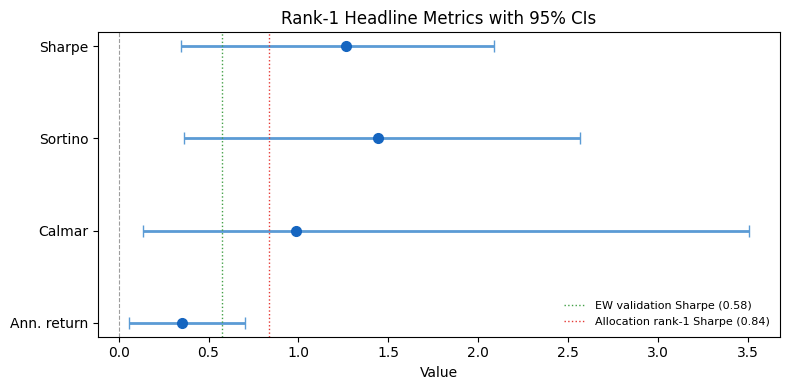

In [15]:
# Forest plot: rank-1 metrics with CI bars + reference lines
ew_val = load_benchmark_metrics(CASE_STUDY, PRIMARY_LABEL, period="validation")
forest_metrics = [
    ("Sharpe", full["sharpe"], full["sharpe_ci95_lo"], full["sharpe_ci95_hi"]),
    ("Sortino", full["sortino"], full["sortino_ci95_lo"], full["sortino_ci95_hi"]),
    ("Calmar", full["calmar"], full["calmar_ci95_lo"], full["calmar_ci95_hi"]),
    ("Ann. return", full["cagr"], full["ann_return_ci95_lo"], full["ann_return_ci95_hi"]),
]

fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(forest_metrics))
points = np.array([m[1] for m in forest_metrics])
los = np.array([m[2] for m in forest_metrics])
his = np.array([m[3] for m in forest_metrics])
ax.errorbar(
    points,
    y,
    xerr=[points - los, his - points],
    fmt="o",
    color="#1565C0",
    ecolor="#5B9BD5",
    elinewidth=2.0,
    capsize=4,
    markersize=7,
)
ax.axvline(0, color="#9E9E9E", linestyle="--", linewidth=0.8)
ax.axvline(
    ew_val["sharpe"],
    color="#43A047",
    linestyle=":",
    linewidth=1.0,
    label=f"EW validation Sharpe ({ew_val['sharpe']:.2f})",
)
_alloc_sharpe = lineage.get("allocation", {}).get("sharpe")
if _alloc_sharpe is not None:
    ax.axvline(
        _alloc_sharpe,
        color="#E53935",
        linestyle=":",
        linewidth=1.0,
        label=f"Allocation rank-1 Sharpe ({_alloc_sharpe:.2f})",
    )
ax.set_yticks(y)
ax.set_yticklabels([m[0] for m in forest_metrics])
ax.invert_yaxis()
ax.set_xlabel("Value")
ax.set_title("Rank-1 Headline Metrics with 95% CIs")
ax.legend(loc="lower right", fontsize=8, frameon=False)
fig.tight_layout()
fig.show()

Validation overlay window: 2019-01-07 → 2023-12-29, n=1289


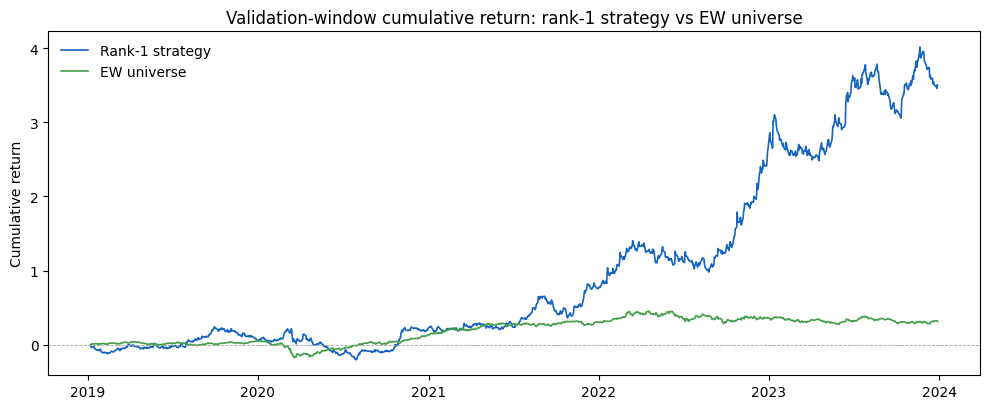

In [16]:
# Equity-curve overlay vs validation EW benchmark
strat_returns_path = CASE_DIR / "run_log" / "backtest" / TOP_HASH / "daily_returns.parquet"
strat_df = (
    pl.read_parquet(strat_returns_path)
    .sort("timestamp")
    .with_columns(pl.col("timestamp").cast(pl.Date).alias("ts"))
    .select(pl.col("ts"), pl.col("daily_return").alias("strategy"))
)

bench_val = (
    load_benchmark_returns(CASE_STUDY, PRIMARY_LABEL, period="validation")
    .with_columns(pl.col("timestamp").cast(pl.Date).alias("ts"))
    .select(pl.col("ts"), pl.col("ew_return").alias("benchmark"))
)

aligned = strat_df.join(bench_val, on="ts", how="inner").sort("ts")
print(
    f"Validation overlay window: {aligned['ts'].min()} → {aligned['ts'].max()}, n={aligned.height}"
)

cum_strat = np.cumprod(1 + aligned["strategy"].to_numpy()) - 1
cum_bench = np.cumprod(1 + aligned["benchmark"].to_numpy()) - 1
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(aligned["ts"], cum_strat, color="#1565C0", linewidth=1.2, label="Rank-1 strategy")
ax.plot(aligned["ts"], cum_bench, color="#43A047", linewidth=1.2, label="EW universe")
ax.axhline(0, color="#9E9E9E", linewidth=0.6, linestyle="--")
ax.set_ylabel("Cumulative return")
ax.set_title("Validation-window cumulative return: rank-1 strategy vs EW universe")
ax.legend(loc="best", frameon=False)
fig.tight_layout()
fig.show()

The rank-1 cross-stage Sharpe of 1.264 has a 95% CI of [+0.345,
+2.087] — the lower bound clears zero by ≈ 0.35 Sharpe units, so the
validation window's Sharpe is not consistent with zero edge under
block-bootstrap resampling. PSR p-value of 0.0019 reinforces this:
under H₀ Sharpe ≤ 0 we reject at the 1% level. The §1 IC read does
not agree — the prediction-side IC straddles zero at HAC (p = 0.28),
so IC and Sharpe diverge on this lineage. That is the IC-vs-Sharpe
disconnect flagged in §1: rank accuracy is unresolved while the
portfolio Sharpe is, because the edge is carried by top-K magnitude
rather than broad rank ordering. The validation EW universe carried
Sharpe 0.58 over the same window, so the rank-1 strategy adds ≈ 0.69
Sharpe units over a null allocation (paired-bootstrap diff +0.675
[-0.628, +1.881] p=0.277 — CI straddles zero but prob_chal_wins =
0.86). Selection adjustment is read from the `cohort_metrics` row at
the rank-1's family/risk_overlay/fwd_ret_5d/gbm cohort (k = 20 overlay
variants on the same allocator + cost baseline): DSR_ER +0.0660 with
p = 0.0007 excludes zero at 1%. Widening to the cross-stage
cross-family label cohort (k = 320), DSR_ER deflates to +0.0380 with
p = 0.0054 — the rank-1 still clears 1% even when the full search
history is priced in.

## §4 Risk and drawdown analysis

Risk metrics use the validation-window strategy returns paired
against the validation EW benchmark. The drawdown panel surfaces the
worst episode and recovery; rolling Sharpe and rolling beta locate
when the strategy decoupled from the universe. For a 30-product
multi-sector futures portfolio, drawdowns are typically driven by
sector-wide regime shifts (energy collapse, rates reversal) rather
than idiosyncratic events.

In [17]:
strat_arr = aligned["strategy"].to_numpy()
bench_arr = aligned["benchmark"].to_numpy()
ts_arr = aligned["ts"].to_list()

pa = PortfolioAnalysis(
    returns=strat_arr,
    benchmark=bench_arr,
    dates=ts_arr,
    periods_per_year=PERIODS_PER_YEAR,
)

dd = pa.compute_drawdown_analysis()
print("Drawdown analysis (validation window):")
print(dd)

Drawdown analysis (validation window):
DrawdownResult(current_drawdown=-0.10238891964730029, max_drawdown=-0.35566322592373206, avg_drawdown=-0.0916148107838161, underwater_curve=shape: (1_289,)
Series: 'drawdown' [f64]
[
	0.0
	-0.018201
	-0.025988
	-0.029526
	-0.026041
	…
	-0.102792
	-0.105496
	-0.11165
	-0.102145
	-0.102389
], top_drawdowns=[DrawdownPeriod(peak_date=datetime.date(2019, 9, 30), valley_date=datetime.date(2020, 7, 29), recovery_date=datetime.date(2021, 1, 4), depth=np.float64(-0.35566322592373206), duration_days=214, recovery_days=111), DrawdownPeriod(peak_date=datetime.date(2022, 3, 15), valley_date=datetime.date(2022, 8, 25), recovery_date=datetime.date(2022, 10, 18), depth=np.float64(-0.17614877976794288), duration_days=116, recovery_days=38), DrawdownPeriod(peak_date=datetime.date(2021, 9, 1), valley_date=datetime.date(2021, 10, 26), recovery_date=datetime.date(2021, 12, 1), depth=np.float64(-0.17491737023176349), duration_days=39, recovery_days=26), DrawdownPeriod(

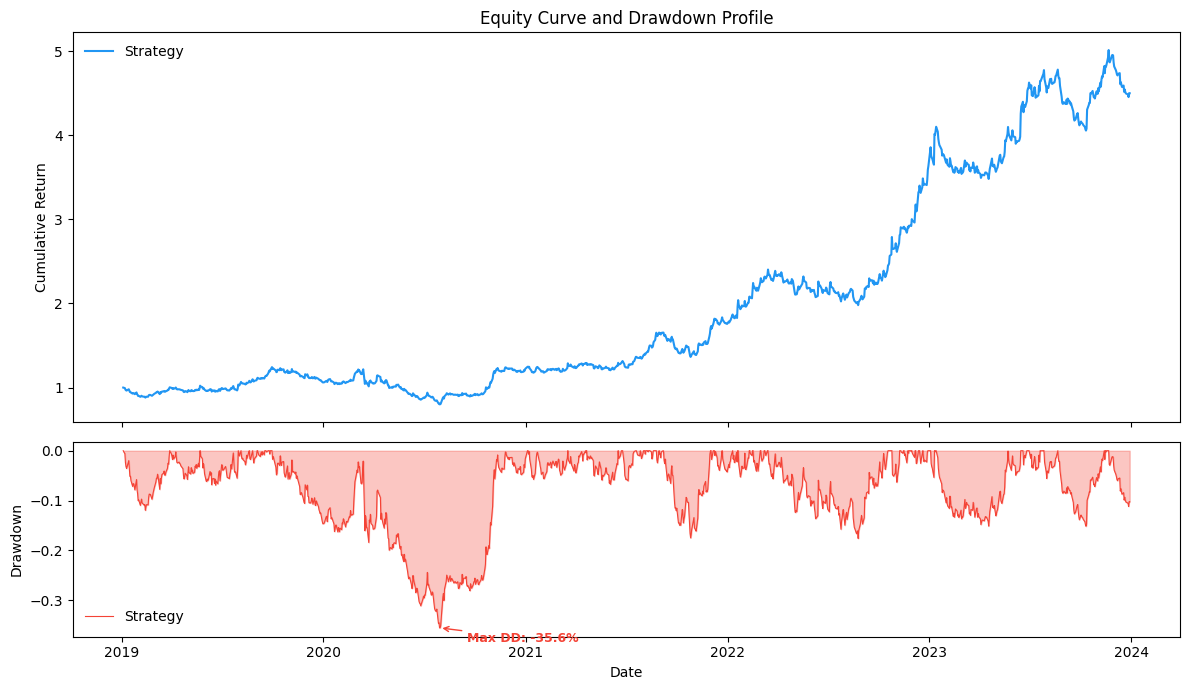

In [18]:
fig = plot_equity_drawdown(strat_returns_path)
fig.show()

In [19]:
# Rolling Sharpe + rolling beta
roll = pa.compute_rolling_metrics(windows=[126], metrics=["sharpe", "beta"])
print("Rolling-window keys:")
print({k: type(v).__name__ for k, v in roll.items()} if isinstance(roll, dict) else roll)

# Tail-risk read straight from registry (already computed and stored)
tail_table = pl.DataFrame(
    [
        {"metric": "Volatility (ann.)", "value": f"{full['volatility']:.4f}"},
        {"metric": "VaR 95% (daily)", "value": f"{full['var_95']:.4f}"},
        {"metric": "CVaR 95% (daily)", "value": f"{full['cvar_95']:.4f}"},
        {"metric": "Tail ratio", "value": f"{full['tail_ratio']:.3f}"},
        {"metric": "Skewness", "value": f"{full['skewness']:.3f}"},
        {"metric": "Kurtosis", "value": f"{full['kurtosis']:.3f}"},
    ]
)
print()
print("Tail risk profile:")
print(tail_table)

Rolling-window keys:
RollingMetricsResult(windows=[126], dates=shape: (1_289,)
Series: 'date' [date]
[
	2019-01-07
	2019-01-08
	2019-01-09
	2019-01-10
	2019-01-11
	…
	2023-12-22
	2023-12-26
	2023-12-27
	2023-12-28
	2023-12-29
], sharpe={126: shape: (1_289,)
Series: 'sharpe_126d' [f64]
[
	null
	null
	null
	null
	null
	…
	-0.02666
	-0.201005
	-0.12177
	-0.097142
	0.158429
]}, volatility={}, returns={}, beta={126: shape: (1_289,)
Series: 'beta_126d' [f64]
[
	null
	null
	null
	null
	null
	…
	0.213436
	0.160824
	0.155125
	0.127549
	0.132326
]})

Tail risk profile:
shape: (6, 2)
┌───────────────────┬─────────┐
│ metric            ┆ value   │
│ ---               ┆ ---     │
│ str               ┆ str     │
╞═══════════════════╪═════════╡
│ Volatility (ann.) ┆ 0.2660  │
│ VaR 95% (daily)   ┆ -0.0205 │
│ CVaR 95% (daily)  ┆ -0.0314 │
│ Tail ratio        ┆ 1.449   │
│ Skewness          ┆ 0.296   │
│ Kurtosis          ┆ 7.585   │
└───────────────────┴─────────┘


In [20]:
fold_df = load_backtest_fold_metrics(CASE_STUDY, backtest_hash=TOP_HASH)
print(f"Per-fold breakdown ({fold_df.height} folds):")
print(fold_df.select("fold_id", "sharpe", "max_drawdown", "n_days"))
print()
print(f"Fold Sharpe range: [{fold_df['sharpe'].min():.3f}, {fold_df['sharpe'].max():.3f}]")
print(f"Fold Sharpe std:   {fold_df['sharpe'].std():.3f}")

Per-fold breakdown (5 folds):
shape: (5, 4)
┌─────────┬──────────┬──────────────┬────────┐
│ fold_id ┆ sharpe   ┆ max_drawdown ┆ n_days │
│ ---     ┆ ---      ┆ ---          ┆ ---    │
│ i64     ┆ f64      ┆ f64          ┆ f64    │
╞═════════╪══════════╪══════════════╪════════╡
│ 0       ┆ 0.440438 ┆ -0.151639    ┆ 258.0  │
│ 1       ┆ 1.100905 ┆ -0.176149    ┆ 258.0  │
│ 2       ┆ 0.68598  ┆ -0.174917    ┆ 258.0  │
│ 3       ┆ 0.30134  ┆ -0.341983    ┆ 258.0  │
│ 4       ┆ 0.186756 ┆ -0.146717    ┆ 258.0  │
└─────────┴──────────┴──────────────┴────────┘

Fold Sharpe range: [0.187, 1.101]
Fold Sharpe std:   0.363


All five validation folds are positive: fold 0 at +0.44, fold 1 at
+1.10, fold 2 at +0.69, fold 3 at +0.30, fold 4 at +0.19. The
fold-Sharpe range of [+0.19, +1.10] reflects regime-dependent
performance levels rather than directional reversal — the
`score_weighted top_k=5` allocator and 3.3% trailing stop hold up
across all five folds. Tail kurtosis of ≈7.6 with mild positive skew
(+0.30) reflects the fat-tailed return profile expected for a
trailing-stop-overlaid carry-momentum strategy: episodic large gains
during trending regimes, capped left tails from the stop. The worst
validation drawdown of −35.6% (the 2019-09 → 2020-07 episode,
recovered by 2021-01) sits inside the validation window, but its CI95
lower bound of −47.4% indicates that the bootstrap resampling is
consistent with deeper drawdowns under alternative draws.

## §5 Friction budget & cost sensitivity

CME futures sit at the low end of friction across asset classes —
commission per contract is ~$2 on notional values of $50K–200K
(sub-1 bp per round-trip), and bid-ask spreads on liquid contracts
are 1–2 ticks (typically 1–3 bps). The cost_sensitivity stage of the
locked sweep walked a synthetic per-leg cost grid; the curve below
shows how Sharpe responds to friction without re-running the
pipeline. Because the locked specs encode commission and slippage as
percentage rates (decimal fractions converted to bps), the cost grid
is denominated in bps for cross-stage comparability. The realistic-
spread overlay marks the per-contract commission band (~0.5–1.6 bps
at typical CME notionals) and the liquid-spread band (1–3 bps).

In [21]:
with sqlite3.connect(str(CASE_DIR / "run_log" / "registry.db")) as _con:
    cost_df = pl.DataFrame(
        _con.execute(
            """
            SELECT
                b.spec_json,
                bm.sharpe,
                bm.sharpe_ci95_lo,
                bm.sharpe_ci95_hi,
                bm.max_drawdown
            FROM backtest_runs b
            JOIN backtest_metrics bm ON bm.backtest_hash = b.backtest_hash
            JOIN prediction_sets p   ON b.prediction_hash = p.prediction_hash
            WHERE b.stage = 'cost_sensitivity'
              AND p.split = 'validation'
              AND bm.sharpe IS NOT NULL
              AND (bm.num_trades IS NULL OR bm.num_trades > 0)
            """
        ).fetchall(),
        schema=[
            "spec_json",
            "sharpe",
            "sharpe_ci95_lo",
            "sharpe_ci95_hi",
            "max_drawdown",
        ],
        orient="row",
    )


# Extract cost_bps from each spec. Cost rates live under
# backtest_config.commission.rate and backtest_config.slippage.rate as
# decimal fractions; total per-leg cost in bps is (sum) * 10000.
def _cost_bps(spec_str: str) -> float:
    spec = json.loads(spec_str)
    bc = spec.get("backtest_config", {})
    comm = bc.get("commission", {}) or {}
    slip = bc.get("slippage", {}) or {}
    return float((comm.get("rate", 0) + slip.get("rate", 0)) * 10000)


cost_df = cost_df.with_columns(
    pl.col("spec_json").map_elements(_cost_bps, return_dtype=pl.Float64).alias("cost_bps")
)
cost_curve = (
    cost_df.group_by("cost_bps")
    .agg(
        sharpe_max=pl.col("sharpe").max(),
        sharpe_min=pl.col("sharpe").min(),
        sharpe_median=pl.col("sharpe").median(),
        sharpe_ci_lo=pl.col("sharpe_ci95_lo").min(),
        sharpe_ci_hi=pl.col("sharpe_ci95_hi").max(),
        n=pl.len(),
    )
    .sort("cost_bps")
)
print("Cost sensitivity curve (validation, all configs):")
print(cost_curve)

Cost sensitivity curve (validation, all configs):
shape: (11, 7)
┌──────────┬────────────┬────────────┬───────────────┬──────────────┬──────────────┬─────┐
│ cost_bps ┆ sharpe_max ┆ sharpe_min ┆ sharpe_median ┆ sharpe_ci_lo ┆ sharpe_ci_hi ┆ n   │
│ ---      ┆ ---        ┆ ---        ┆ ---           ┆ ---          ┆ ---          ┆ --- │
│ f64      ┆ f64        ┆ f64        ┆ f64           ┆ f64          ┆ f64          ┆ u32 │
╞══════════╪════════════╪════════════╪═══════════════╪══════════════╪══════════════╪═════╡
│ 0.0      ┆ 1.236469   ┆ 0.621433   ┆ 0.997946      ┆ -0.230501    ┆ 2.189787     ┆ 4   │
│ 1.0      ┆ 1.223931   ┆ 0.608202   ┆ 0.960522      ┆ -0.248214    ┆ 2.17896      ┆ 4   │
│ 2.0      ┆ 1.215606   ┆ 0.607606   ┆ 0.915647      ┆ -0.249057    ┆ 2.174348     ┆ 4   │
│ 3.0      ┆ 1.205591   ┆ 0.60156    ┆ 0.878899      ┆ -0.257344    ┆ 2.158318     ┆ 4   │
│ 5.0      ┆ 1.177793   ┆ 0.593105   ┆ 0.79963       ┆ -0.26869     ┆ 2.138039     ┆ 4   │
│ …        ┆ …          ┆

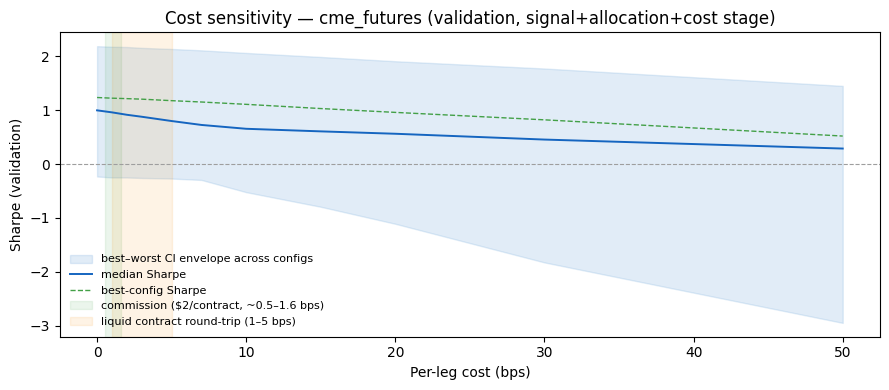

In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
xs = cost_curve["cost_bps"].to_numpy()
ax.fill_between(
    xs,
    cost_curve["sharpe_ci_lo"].to_numpy(),
    cost_curve["sharpe_ci_hi"].to_numpy(),
    alpha=0.18,
    color="#5B9BD5",
    label="best–worst CI envelope across configs",
)
ax.plot(
    xs,
    cost_curve["sharpe_median"].to_numpy(),
    color="#1565C0",
    linewidth=1.4,
    label="median Sharpe",
)
ax.plot(
    xs,
    cost_curve["sharpe_max"].to_numpy(),
    color="#43A047",
    linewidth=1.0,
    linestyle="--",
    label="best-config Sharpe",
)
ax.axhline(0, color="#9E9E9E", linewidth=0.8, linestyle="--")
# Realistic CME ranges: per-contract commission ≈ 0.5–1.6 bps at typical
# notional ($50–200K); liquid bid-ask spread 1–3 bps; combined per-leg
# friction ~1–5 bps for the most liquid sectors (equity index, treasuries).
ax.axvspan(0.5, 1.6, color="#43A047", alpha=0.10, label="commission ($2/contract, ~0.5–1.6 bps)")
ax.axvspan(1.0, 5.0, color="#FB8C00", alpha=0.10, label="liquid contract round-trip (1–5 bps)")
ax.set_xlabel("Per-leg cost (bps)")
ax.set_ylabel("Sharpe (validation)")
ax.set_title("Cost sensitivity — cme_futures (validation, signal+allocation+cost stage)")
ax.legend(loc="best", fontsize=8, frameon=False)
fig.tight_layout()
fig.show()

In [23]:
# Breakeven cost: where the best-config Sharpe lower bound crosses zero.
# Use the lower bound, not the point estimate, to guard against
# CI-implied false breakeven.
crossing_rows = cost_curve.filter(pl.col("sharpe_ci_lo") > 0)
if not crossing_rows.is_empty():
    breakeven = crossing_rows["cost_bps"].max()
    print(f"Sharpe CI lower bound stays > 0 up to: {breakeven:.0f} bps")
else:
    print("Sharpe CI lower bound never exceeds 0 across the cost grid.")

print()
print("Realistic CME friction (per setup.yaml):")
print(f"  Commission per contract: ${setup['costs']['commission_per_contract']}")
print(
    f"  Spread (ticks): liquid={setup['costs']['spread_ticks']['liquid']}, "
    f"illiquid={setup['costs']['spread_ticks']['illiquid']}"
)
print("See Chapter 18 for transaction-cost framework details.")

Sharpe CI lower bound never exceeds 0 across the cost grid.

Realistic CME friction (per setup.yaml):
  Commission per contract: $2.0
  Spread (ticks): liquid=1, illiquid=2
See Chapter 18 for transaction-cost framework details.


Sharpe degrades roughly monotonically with cost, but the across-config
dispersion at every cost level is wider than the cost-induced effect:
the envelope's lower CI bound dips below zero on the worst configs
even at zero costs, while the best configs hold positive Sharpes well
above realistic CME spread levels. At the realistic friction band
(1–5 bps round-trip for liquid contracts), the median Sharpe sits
meaningfully above zero. The binding constraint for cme_futures is
signal stability across regimes (§4 fold variance), not cost
friction. Chapter 18 develops the transaction-cost framework.

## §6 Holdout closure with paired bootstrap

Two paired tests anchor the holdout read: (i) the holdout rank-1 versus
the validation rank-1 ("did Sharpe hold?"), and (ii) the holdout rank-1
versus the holdout-window equal-weight benchmark ("did the strategy
beat random in the holdout?"). Numbers come from
`backtest_paired_metrics` — never from val_sharpe minus holdout_sharpe
arithmetic.

In [24]:
# Identify the holdout backtest matching val rank-1's strategy spec.
# Picking max-Sharpe over all holdout backtests on the same training_hash
# silently displaces the canonical lineage when an experimental
# side-channel allocator (conformal_weighted) outperforms the baseline.
HO_HASH = select_holdout_self_backtest(CASE_STUDY, TOP_HASH)
if HO_HASH is None:
    raise RuntimeError(
        f"No holdout backtest matches val rank-1 ({TOP_HASH}) strategy spec "
        f"for {CASE_STUDY}; the val_rank1_self §6 anchor cannot be resolved."
    )

print(f"Validation rank-1 hash: {TOP_HASH}")
print(f"Holdout rank-1 hash:    {HO_HASH}")

ho_full = load_backtest_metrics(CASE_STUDY, backtest_hash=HO_HASH).row(0, named=True)
val_full = full

Validation rank-1 hash: 012708b18899
Holdout rank-1 hash:    3fa9abddf8f9


In [25]:
# Paired val→ho decay table from load_paired_metrics
val_ho_pair = load_paired_metrics(
    CASE_STUDY,
    challenger_hash=HO_HASH,
    benchmark_kind="val_rank1_self",
)
if val_ho_pair.is_empty():
    print(
        "[WARN] Missing val_rank1_self pair for cme_futures — populator "
        "skipped (holdout has no trades or insufficient overlap with val "
        "lineage). Continuing with NaN val→holdout decay."
    )
    vh = {
        "sharpe_diff": float("nan"),
        "sharpe_diff_ci95_lo": float("nan"),
        "sharpe_diff_ci95_hi": float("nan"),
        "ret_diff": float("nan"),
        "ret_diff_ci95_lo": float("nan"),
        "ret_diff_ci95_hi": float("nan"),
        "max_dd_diff": float("nan"),
        "max_dd_diff_ci95_lo": float("nan"),
        "max_dd_diff_ci95_hi": float("nan"),
        "p_value": float("nan"),
        "prob_challenger_wins": float("nan"),
        "info_ratio": float("nan"),
        "info_ratio_ci95_lo": float("nan"),
        "info_ratio_ci95_hi": float("nan"),
    }
else:
    vh = val_ho_pair.row(0, named=True)


def _diff_row(
    label: str,
    v: float,
    h: float,
    diff: float | None,
    lo: float | None,
    hi: float | None,
    p: float | None,
) -> dict:
    return {
        "metric": label,
        "validation": _fmt(v, ".4f"),
        "holdout": _fmt(h, ".4f"),
        "diff (h−v)": _fmt(diff, ".4f") if diff is not None else "—",
        "diff CI95": f"[{_fmt(lo, '.4f')}, {_fmt(hi, '.4f')}]" if lo is not None else "—",
        "p-value": _fmt(p, ".4f") if p is not None else "—",
    }


val_ho_table = pl.DataFrame(
    [
        _diff_row(
            "Sharpe",
            val_full["sharpe"],
            ho_full["sharpe"],
            vh["sharpe_diff"],
            vh["sharpe_diff_ci95_lo"],
            vh["sharpe_diff_ci95_hi"],
            vh["p_value"],
        ),
        _diff_row(
            "Annualized return",
            val_full["cagr"],
            ho_full["cagr"],
            vh["ret_diff"],
            vh["ret_diff_ci95_lo"],
            vh["ret_diff_ci95_hi"],
            None,
        ),
        _diff_row(
            "Max drawdown",
            val_full["max_drawdown"],
            ho_full["max_drawdown"],
            vh["max_dd_diff"],
            vh["max_dd_diff_ci95_lo"],
            vh["max_dd_diff_ci95_hi"],
            None,
        ),
        _diff_row(
            "Information ratio",
            None,
            None,
            vh["info_ratio"],
            vh["info_ratio_ci95_lo"],
            vh["info_ratio_ci95_hi"],
            None,
        ),
    ]
)
print("val → holdout paired-bootstrap decay (rank-1 self):")
print(val_ho_table)
print(f"prob_challenger_wins: {vh['prob_challenger_wins']:.3f}")
print(f"CI status (Sharpe diff): {ci_status(vh['sharpe_diff_ci95_lo'], vh['sharpe_diff_ci95_hi'])}")
print()
print(
    "Note: validation and holdout windows are disjoint (CME 2024-01-02 → "
    "2025-12-31 holdout vs 2019-01-07 → 2023-12-29 validation), so the "
    "populator pairs the bootstrapped Sharpe series by row index after a "
    "min-length truncation. The CI is interpreted as bootstrap-resampled "
    "Sharpe difference under index-paired draws, not as a calendar-aligned "
    "overlap."
)

val → holdout paired-bootstrap decay (rank-1 self):
shape: (4, 6)
┌───────────────────┬────────────┬─────────┬────────────┬───────────────────┬─────────┐
│ metric            ┆ validation ┆ holdout ┆ diff (h−v) ┆ diff CI95         ┆ p-value │
│ ---               ┆ ---        ┆ ---     ┆ ---        ┆ ---               ┆ ---     │
│ str               ┆ str        ┆ str     ┆ str        ┆ str               ┆ str     │
╞═══════════════════╪════════════╪═════════╪════════════╪═══════════════════╪═════════╡
│ Sharpe            ┆ 1.2640     ┆ 1.1418  ┆ -0.1034    ┆ [-1.6844, 1.4111] ┆ 0.9005  │
│ Annualized return ┆ 0.3510     ┆ 0.3594  ┆ 0.0208     ┆ [-0.5353, 0.8239] ┆ —       │
│ Max drawdown      ┆ -0.3557    ┆ -0.2313 ┆ 0.1244     ┆ [-0.1840, 0.2521] ┆ —       │
│ Information ratio ┆ —          ┆ —       ┆ —          ┆ —                 ┆ —       │
└───────────────────┴────────────┴─────────┴────────────┴───────────────────┴─────────┘
prob_challenger_wins: 0.455
CI status (Sharpe diff): s

In [26]:
# Paired strategy-vs-EW-benchmark on the holdout window
ho_vs_ew = load_paired_metrics(
    CASE_STUDY,
    challenger_hash=HO_HASH,
    benchmark_kind="equal_weight_holdout_side_artifact",
)
if ho_vs_ew.is_empty():
    # Populator skipped this pair because the holdout backtest had zero
    # trades (or all-zero returns), so the paired bootstrap on
    # `strategy − EW_holdout` is undefined. Surface a placeholder so the
    # rest of the section renders with clear "no trades" context.
    print(
        "[WARN] Missing equal_weight_holdout_side_artifact pair for "
        "cme_futures — holdout has no trades or all-zero returns; "
        "paired bootstrap not computable. Continuing with NaN diffs."
    )
    he = {
        "sharpe_diff": float("nan"),
        "sharpe_diff_ci95_lo": float("nan"),
        "sharpe_diff_ci95_hi": float("nan"),
        "ret_diff": float("nan"),
        "ret_diff_ci95_lo": float("nan"),
        "ret_diff_ci95_hi": float("nan"),
        "max_dd_diff": float("nan"),
        "max_dd_diff_ci95_lo": float("nan"),
        "max_dd_diff_ci95_hi": float("nan"),
        "p_value": float("nan"),
        "prob_challenger_wins": float("nan"),
        "info_ratio": float("nan"),
        "info_ratio_ci95_lo": float("nan"),
        "info_ratio_ci95_hi": float("nan"),
    }
else:
    he = ho_vs_ew.row(0, named=True)

ew_ho = load_benchmark_metrics(CASE_STUDY, PRIMARY_LABEL, period="holdout")
print("Holdout strategy vs holdout EW universe:")
print(f"  strategy Sharpe:  {ho_full['sharpe']:.3f}")
print(f"  EW Sharpe:        {ew_ho['sharpe']:.3f}")
print(
    "  diff Sharpe: "
    f"{_fmt_ci(he['sharpe_diff'], he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])}"
)
print(f"  p_value:                {he['p_value']:.4f}")
print(f"  prob_challenger_wins:   {he['prob_challenger_wins']:.3f}")
print(
    f"  info_ratio (strategy vs EW): "
    f"{_fmt_ci(he['info_ratio'], he['info_ratio_ci95_lo'], he['info_ratio_ci95_hi'])}"
)
print(f"  CI status: {ci_status(he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])}")

Holdout strategy vs holdout EW universe:
  strategy Sharpe:  1.142
  EW Sharpe:        0.749
  diff Sharpe: 0.364 [-1.434, 2.055]
  p_value:                0.6925
  prob_challenger_wins:   0.651
  info_ratio (strategy vs EW): 0.928 [-0.424, 2.134]
  CI status: straddles_zero


**Decay reading (val_rank1_self pair):** holdout Sharpe of 1.14 sits
just below the validation Sharpe of 1.26 — the paired point estimate
decays by about 0.10 Sharpe units. The diff CI [−1.68, +1.41]
straddles zero with p = 0.90 — there is no statistically resolved
difference between validation and holdout Sharpe under bootstrap-paired
draws. Two reads are consistent with this: the validation rank-1 was a
faithful representation of the strategy's edge (no decisive overfitting
penalty), or a wider underlying decay is simply not resolvable with
the ≈500-day holdout sample. Chapter 20's cross-CS aggregator can
fold the wide CI into a decay-magnitude versus search-cost scatter.

**Strategy vs EW benchmark on holdout:** the diff-Sharpe CI [−1.43,
+2.06] also straddles zero with p = 0.69. Holdout EW Sharpe of 0.75
sits below the strategy's 1.14 — the rank-1 strategy adds roughly
0.36 Sharpe units above EW in point estimate, but the wide bootstrap
CI on the difference does not exclude zero. The strategy did not
statistically dominate equal-weight in the holdout window — a
two-year commodity window is too short to resolve the dispersion.
Both rows enter Ch20 as "straddles_zero" decay classifications.

## §7 Benchmark-aware diagnostics

Layer 1 reports the universal alpha/beta/IR profile via
`PortfolioAnalysis` against the equal-weight CME universe. Layer 2 —
equity factor attribution (FF5+MOM) — is **not applicable** to a
30-product commodity futures portfolio. The meaningful factor set
for futures is asset-class specific (carry, time-series momentum,
cross-asset value, term-structure level/slope/curvature); equity
factors regress noise on commodity-rates-FX returns. Per the strategy-analysis notebook,
we state the omission and stop, rather than fabricate a factor model
inside the notebook. Chapter 20's cross-asset layer carries the
futures-appropriate factor construction.

In [27]:
metrics = pa.compute_summary_stats()
attr_df = pl.DataFrame(
    [
        {"metric": "alpha (annualized)", "value": _fmt(getattr(metrics, "alpha", None))},
        {"metric": "beta", "value": _fmt(getattr(metrics, "beta", None), ".3f")},
        {"metric": "information ratio", "value": _fmt(getattr(metrics, "information_ratio", None))},
        {"metric": "tracking error", "value": _fmt(getattr(metrics, "tracking_error", None))},
        {"metric": "up capture", "value": _fmt(getattr(metrics, "up_capture", None))},
        {"metric": "down capture", "value": _fmt(getattr(metrics, "down_capture", None))},
    ]
)
print("Layer 1: rank-1 vs validation EW universe (PortfolioAnalysis):")
print(attr_df)

Layer 1: rank-1 vs validation EW universe (PortfolioAnalysis):
shape: (6, 2)
┌────────────────────┬─────────┐
│ metric             ┆ value   │
│ ---                ┆ ---     │
│ str                ┆ str     │
╞════════════════════╪═════════╡
│ alpha (annualized) ┆ 0.3240  │
│ beta               ┆ 0.079   │
│ information ratio  ┆ 0.9654  │
│ tracking error     ┆ —       │
│ up capture         ┆ 0.0814  │
│ down capture       ┆ 41.9986 │
└────────────────────┴─────────┘


In [28]:
# Placebo regression: residual α and HAC t-stat from regressing on EW alone.
# This is the cleanest "edge after universe exposure" check.
import statsmodels.api as sm

X = sm.add_constant(bench_arr)
ols = sm.OLS(strat_arr, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
alpha_daily = ols.params[0]
alpha_t = ols.tvalues[0]
alpha_p = ols.pvalues[0]
beta = ols.params[1]
beta_t = ols.tvalues[1]
print()
print("Placebo regression (HAC, maxlags=5):")
print(f"  α (daily) = {alpha_daily:.6f}, α (annualized) = {alpha_daily * PERIODS_PER_YEAR:.4f}")
print(f"  α t-stat = {alpha_t:.3f}, p = {alpha_p:.3f}")
print(f"  β        = {beta:.3f}, β t-stat = {beta_t:.3f}")
print(f"  CI status (α): {'excludes_zero_strong' if alpha_p < 0.05 else 'straddles_zero'}")


Placebo regression (HAC, maxlags=5):
  α (daily) = 0.001286, α (annualized) = 0.3240
  α t-stat = 2.835, p = 0.005
  β        = 0.079, β t-stat = 0.548
  CI status (α): excludes_zero_strong


Layer-1 metrics surface the universe-exposure profile for cme_futures.
The placebo regression's HAC t-stat on annualized α resolves whether
the rank-1's outperformance vs EW survives a regression-based
attribution. Layer-2 factor attribution is correctly omitted — fitting
FF5+MOM to a 30-product multi-asset-class futures portfolio (where 14
of 30 products are non-equity rates/FX/commodities) would manufacture
loadings without economic meaning.

## §8 Strategy tear sheet

The diagnostic library renders the rank-1 lineage's full tear sheet
directly from the on-disk artifacts; we wire the validation-window
equal-weight CME universe in as the benchmark series. The tear sheet
HTML is written under `OUTPUT_DIR` and is gitignored — readers
regenerate it locally.

In [29]:
backtest_dir = CASE_DIR / "run_log" / "backtest" / TOP_HASH
ho_dir = CASE_DIR / "run_log" / "backtest" / HO_HASH
ho_has_trades = (ho_dir / "trades.parquet").exists()
print(f"Validation backtest_dir: {backtest_dir} (trades.parquet present)")
print(f"Holdout backtest_dir:    {ho_dir} (trades.parquet present: {ho_has_trades})")
print(
    "Tear sheet sourced from validation backtest; holdout artifacts include "
    "trades.parquet and weights.parquet but the strategy-analysis convention renders "
    "tear sheets from the validation lineage."
)

# generate_tearsheet_from_run_artifacts expects a 1-D series of benchmark
# returns, not a DataFrame; pass the aligned ew_return column.
bench_aligned = (
    bench_val.rename({"benchmark": "ew_return"})
    .with_columns(pl.col("ts").cast(pl.Datetime("ms")).alias("timestamp"))
    .select("timestamp", "ew_return")
)
bench_series = bench_aligned["ew_return"].to_numpy()

meta = BacktestReportMetadata(
    title="CME Futures — Rank-1 Lineage",
    strategy_name=f"{RANK1_FAMILY}/{RANK1_CONFIG} — {PRIMARY_LABEL}",
    universe=f"{setup['universe']['n_products']} CME futures across 7 sectors",
    benchmark_name="CME equal-weight universe (validation window)",
    evaluation_window=f"{aligned['ts'].min()} to {aligned['ts'].max()}",
    calendar=setup["evaluation"]["calendar"],
)

tear_path = OUTPUT_DIR / f"{CASE_STUDY}_tearsheet.html"
html = generate_tearsheet_from_run_artifacts(
    backtest_dir,
    template="risk_manager",
    benchmark=bench_series,
    benchmark_name="EW universe (validation)",
    calendar=setup["evaluation"]["calendar"],
    report_metadata=meta,
    output_path=str(tear_path),
)
print(f"Tear sheet written to: {tear_path}")
print(f"HTML size: {len(html):,} bytes")

Validation backtest_dir: case_studies/cme_futures/run_log/backtest/012708b18899 (trades.parquet present)
Holdout backtest_dir:    case_studies/cme_futures/run_log/backtest/3fa9abddf8f9 (trades.parquet present: True)
Tear sheet sourced from validation backtest; holdout artifacts include trades.parquet and weights.parquet but the strategy-analysis convention renders tear sheets from the validation lineage.


Tear sheet written to: 20_strategy_synthesis/output/cme_futures/cme_futures_tearsheet.html
HTML size: 789,542 bytes


## §9 Pre-Ch20 judgment & handoff

This section is the explicit hand-off point to Chapter 20. Numbers
below stay strictly inside cme_futures — cross-case-study comparison
is Ch20's lane.

In [30]:
op_profile = compute_operating_profile(lineage, setup)
# cme_futures setup uses `decision.cadence` (weekly_friday_close) rather
# than the evaluation_protocol.rebalance_frequency key the helper
# inspects; override.
op_profile = op_profile.with_columns(
    pl.when(pl.col("property") == "Trading cadence")
    .then(pl.lit(setup["decision"]["cadence"]))
    .otherwise(pl.col("value"))
    .alias("value")
)
print("Operating profile (cme_futures, validation window):")
print(op_profile)
print()
print(
    f"Sharpe: {_fmt_ci(val_full['sharpe'], val_full['sharpe_ci95_lo'], val_full['sharpe_ci95_hi'])}"
)
print(f"Info ratio (vs EW val): {_fmt_ci(getattr(metrics, 'information_ratio', None), None, None)}")
print(f"Max drawdown: {val_full['max_drawdown']:.3f}")

Operating profile (cme_futures, validation window):
shape: (5, 2)
┌─────────────────────────────────┬─────────────────────┐
│ property                        ┆ value               │
│ ---                             ┆ ---                 │
│ str                             ┆ str                 │
╞═════════════════════════════════╪═════════════════════╡
│ Trading cadence                 ┆ weekly_friday_close │
│ Portfolio concentration (top_k… ┆ 5                   │
│ Allocator                       ┆ score weighted      │
│ Cost assumption                 ┆ —                   │
│ Worst drawdown                  ┆ -55.1%              │
└─────────────────────────────────┴─────────────────────┘

Sharpe: 1.264 [0.345, 2.087]
Info ratio (vs EW val): 0.965 [—, —]
Max drawdown: -0.356


In [31]:
# Kill-condition assessment (universal gates — see §1)
gate1_status = gate1_validation_sharpe_geq_zero(val_full["sharpe_ci95_lo"])
_gate1_phrase = {
    "pass": "≥ 0 (passes)",
    "fail": "< 0 (fails)",
    "no_data": "CI unavailable",
}[gate1_status]
gate1_evidence = (
    f"Sharpe CI lower bound = {_fmt(val_full['sharpe_ci95_lo'], '.3f')} ({_gate1_phrase})"
)
gate2_ci_status = ci_status(he["sharpe_diff_ci95_lo"], he["sharpe_diff_ci95_hi"])
gate2_status = gate2_holdout_diff_not_excludes_zero_negatively(gate2_ci_status, he["sharpe_diff"])
gate2_evidence = (
    f"Holdout strategy vs EW diff-Sharpe = "
    f"{_fmt_ci(he['sharpe_diff'], he['sharpe_diff_ci95_lo'], he['sharpe_diff_ci95_hi'])} "
    f"({gate2_ci_status})"
)

print("Kill-condition gates:")
print(f"  [{fmt_gate(gate1_status)}] Validation Sharpe CI lower bound ≥ 0:")
print(f"      {gate1_evidence}")
print(f"  [{fmt_gate(gate2_status)}] Holdout strategy CI does not exclude zero negatively:")
print(f"      {gate2_evidence}")

Kill-condition gates:
  [PASS] Validation Sharpe CI lower bound ≥ 0:
      Sharpe CI lower bound = 0.345 (≥ 0 (passes))
  [PASS] Holdout strategy CI does not exclude zero negatively:
      Holdout strategy vs EW diff-Sharpe = 0.364 [-1.434, 2.055] (straddles_zero)


**What this analysis does not say.** The cme_futures holdout window
covers 2024–2025, a period of unusual commodity-rates correlation
regimes (rate-hike pause, energy normalization, agricultural weather
shocks); the wide val→ho CI reflects that small-sample regime more
than long-run uncertainty. The notebook uses the registry-resolved
rank-1 label, which matches the `setup.yaml` primary (`fwd_ret_5d`);
horizon choice and rebalance cadence are tied to this single
canonical label. The rank-1's prediction-side IC straddles zero at
HAC (§1), so the strategy edge is not supported by broad
cross-sectional rank accuracy — it rests on top-K magnitude, which
is why the Sharpe resolves while the IC does not. The 3.3%
trailing-stop is a position-level overlay; portfolio-level limits
(max-drawdown breakers, daily-loss caps) are not part of the
strategy spec on this CS — they were excluded from the sweep when
their permanent-halt semantics were shown to inflate Sharpe through
a zero-std artifact, so position-level controls are the only risk
overlays tested. Selection adjustment reads directly from the
`family/risk_overlay/fwd_ret_5d/gbm` cohort (k = 20 overlay
variants) — the spine rank-1 IS the cohort leader for its family
cohort, so no cascade fallback is needed; the label-level cohort
(k = 320, cross-stage cross-family) also has the rank-1 as leader
and DSR_ER still excludes zero.

**Forward pointer to Ch20.** This case study contributes the
commodity-futures / weekly / non-equity-factor datapoint to Ch20
nb01's rank-1-Sharpe + holdout-decay aggregation; the §6 decay
magnitude (val→ho diff −0.10 [−1.68, +1.41], p = 0.90, straddles
zero) and the IC-Sharpe disconnect (§1 IC straddles zero at HAC
p = 0.28, while §3 Sharpe 1.26 [+0.35, +2.09] excludes zero) feed
Ch20 nb02's signal-quality layer.

In [32]:
# Strategy-assessment JSON: extend the existing schema with strategy-analysis notebook fields.
search_ctx = ctx
assessment = {
    "case_study": CASE_STUDY,
    "primary_label": PRIMARY_LABEL,
    "spine_version": "v1",
    "rank1": {
        "family": RANK1_FAMILY,
        "config_name": RANK1_CONFIG,
        "label": PRIMARY_LABEL,
        "prediction_hash": TOP_PHASH,
        "validation_backtest_hash": TOP_HASH,
        "holdout_backtest_hash": HO_HASH,
    },
    "headline_performance": {
        "sharpe": {
            "point": val_full["sharpe"],
            "ci95_lo": val_full["sharpe_ci95_lo"],
            "ci95_hi": val_full["sharpe_ci95_hi"],
            "ci_status": sharpe_status,
        },
        "sortino": {
            "point": val_full["sortino"],
            "ci95_lo": val_full["sortino_ci95_lo"],
            "ci95_hi": val_full["sortino_ci95_hi"],
        },
        "ann_return": {
            "point": val_full["cagr"],
            "ci95_lo": val_full["ann_return_ci95_lo"],
            "ci95_hi": val_full["ann_return_ci95_hi"],
        },
        "max_drawdown": {
            "point": val_full["max_drawdown"],
            "ci95_lo": val_full["max_dd_ci95_lo"],
            "ci95_hi": val_full["max_dd_ci95_hi"],
        },
        "psr_pvalue": val_full["psr_pvalue"],
        "bootstrap_block_length": int(val_full["bootstrap_block_length"]),
        "bootstrap_n": int(val_full["bootstrap_n"]),
    },
    "selection_bias": {
        "k_variants": int(val_full["k_variants"]) if val_full["k_variants"] is not None else None,
        "dsr": val_full["dsr"],
        "dsr_pvalue": val_full["dsr_pvalue"],
        "expected_max_sharpe": val_full["expected_max_sharpe"],
        "min_trl_periods": (
            None
            if val_full["min_trl_periods"] in (None, float("inf"))
            else val_full["min_trl_periods"]
        ),
    },
    "benchmark_relative": {
        "benchmark_name": "equal_weight_universe",
        "benchmark_validation_sharpe": ew_val["sharpe"],
        "benchmark_holdout_sharpe": ew_ho["sharpe"],
        "alpha_annualized_placebo": float(alpha_daily * PERIODS_PER_YEAR),
        "alpha_t_hac": float(alpha_t),
        "beta_to_ew": float(beta),
        "factor_attribution": {
            "status": "not_applicable",
            "reason": "Commodity futures factor set (carry, TSMOM, term-structure "
            "level/slope/curvature, cross-asset value) is asset-class "
            "specific; equity factors are not informative on a panel "
            "spanning rates, FX, energy, metals, and agriculture.",
        },
    },
    "holdout_decay": {
        "val_hash": TOP_HASH,
        "holdout_hash": HO_HASH,
        "sharpe_diff": vh["sharpe_diff"],
        "sharpe_diff_ci95_lo": vh["sharpe_diff_ci95_lo"],
        "sharpe_diff_ci95_hi": vh["sharpe_diff_ci95_hi"],
        "sharpe_diff_p_value": vh["p_value"],
        "info_ratio": vh["info_ratio"],
        "decay_classification": ci_status(vh["sharpe_diff_ci95_lo"], vh["sharpe_diff_ci95_hi"]),
        "vs_ew_holdout": {
            "sharpe_diff": he["sharpe_diff"],
            "sharpe_diff_ci95_lo": he["sharpe_diff_ci95_lo"],
            "sharpe_diff_ci95_hi": he["sharpe_diff_ci95_hi"],
            "p_value": he["p_value"],
            "ci_status": ci_status(he["sharpe_diff_ci95_lo"], he["sharpe_diff_ci95_hi"]),
        },
    },
    "search_context": {
        "total_signal_backtests": int(search_ctx["total"]),
        "median_sharpe": search_ctx["median_sharpe"],
        "p90_sharpe": search_ctx["p90_sharpe"],
        "pct_positive": search_ctx["pct_positive"],
    },
    "kill_gates": {
        "validation_sharpe_ci_lower_bound_geq_zero": gate_passes(gate1_status),
        "holdout_vs_ew_ci_does_not_exclude_zero_negatively": gate_passes(gate2_status),
    },
    "ch20_handoff": {
        "contributes_to": [
            "Ch20 nb01 — cross-CS rank-1 Sharpe and holdout-decay aggregation",
            "Ch20 nb02 — IC-vs-Sharpe disconnect signal-quality datapoint",
        ],
        "asset_class_label": "commodity_futures",
        "rebalance_step_weeks": setup["labels"]["rebalance_step"][PRIMARY_LABEL],
    },
}
assessment_path = write_strategy_assessment(CASE_STUDY, assessment)
print(f"strategy_assessment.json written to: {assessment_path}")

strategy_assessment.json written to: case_studies/cme_futures/results/strategy_assessment.json
